# Go Game Review Analyser

Date: `2026-03-25`

Author: `@sthornewillve`

This notebook is the prototype that takes go games analysed and creates a database from them in order to analyse.

___

# Setup Notebook

In [1]:
import os
import json
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt

from openai import OpenAI
from go_game_analyser_helperfuncs import analyse_game_review_summary

In [2]:
# Create OpenAI Connection
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

# Import prompts
with open("prompt_configs.json") as f:
    prompts = json.load(f)

In [3]:
# Get game review summaries
conn = sqlite3.connect("game_reviews.db")
game_review_df = pd.read_sql("SELECT * FROM reviews", conn)
game_review_df.head()

,date,opponents_name,server,game_link,result,played_as,handicap,time_setting,review_notes,key_mistake,key_mistake_cause,positive_point,game_tags
0,2026-03-24,dienfoonwu,OGS,https://ai-sensei.com/game/VGIPT5au1Jg6jxQRo6P...,B+R,White,3,20m + 5x30s,\n* End of game notes\n\t* Got surrounded and ...,Letting atari surround my group,Poor defense against atari,Exploited opponent's weak shape,Allowed group to get surrounded; Endgame troub...
1,2026-03-23,Yaryk1111_,OGS,https://ai-sensei.com/game/VGIPT5au1Jg6jxQRo6P...,B+2.5,Black,0,20m + 5x30s,\n* End of game notes\n\t* Black has a large l...,Attachment to shimari as ladder breaker,tried to salvage with attachment instead of co...,Handled the running battle better than White,Exploited opponent's weak shape; Ko situation;...
2,2026-03-24,njbigboy,OGS,https://ai-sensei.com/game/VGIPT5au1Jg6jxQRo6P...,W+T,White,1,10m + 10s/mv,\n* End of game notes\n\t* Died with a deep in...,Died with a deep invasion,abandoning deep invasion,Nice framework on the left side,Opponent ran out of time; Played calmly; Built...
3,2026-03-25,이송희,OGS,https://ai-sensei.com/game/VGIPT5au1Jg6jxQRo6P...,W+5.5,Black,0,20m + 5x30s,\n* End of game notes\n\t* Black and white tra...,Ending in gote,Endgame misjudgment leading to gote,Captured White's center group in the opening,Lost points in endgame; Endgame trouble; Compl...


___

# Analyse Games

In [4]:
analyse_game_review_summary(game_review_df, client, prompts)

{'did_well': 'You consistently press opponent weaknesses and stay calm under pressure, turning early structural gains into solid frameworks and favorable battles across different games.',
 'needs_work': 'Improve endgame discipline and life-and-death accuracy to avoid surrounded groups or endings in gote, and avoid overcommitting to invasions or attachment maneuvers when simpler local play is available.'}

In [5]:
tag_counts = (
    game_review_df["game_tags"]
    .str.split(";")
    .explode()
    .str.strip()
    .value_counts()
    .to_dict()
)

tag_counts

{'Endgame trouble': 2,
 "Exploited opponent's weak shape": 2,
 'Allowed group to get surrounded': 1,
 'Died with surrounded group': 1,
 'Ko situation': 1,
 'Outplayed opponent': 1,
 'Withstood aggressive player': 1,
 'Opponent ran out of time': 1,
 'Played calmly': 1,
 'Built large framework': 1,
 'Lost points in endgame': 1,
 'Complicated the game': 1}

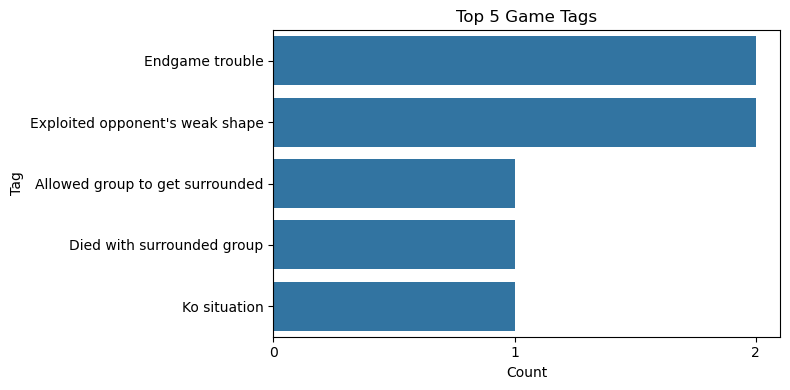

In [6]:
top5 = sorted(tag_counts.items(), key=lambda x: x[1], reverse=True)[:5]
tags, counts = zip(*top5)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=list(counts), y=list(tags), ax=ax)
ax.set(title="Top 5 Game Tags", xlabel="Count", ylabel="Tag")
ax.xaxis.set_major_locator(plt.MultipleLocator(1))
plt.tight_layout()
plt.show()